<a href="https://colab.research.google.com/github/JordanCodeGit/ContextSarcasmDetector/blob/main/FinalProjectAI_2311102139_2311102179.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Melampaui Klasifikasi Biner: Analisis Deteksi Sarkasme Sadar Konteks pada Hiperbola dan Pertanyaan Retoris dalam Diskusi Daring**
**Pencipta:** Jordan Angkawijaya (2311102139) & Axandio Biyanatul Lizan (2311102179)

---

## **1. Abstrak**
Studi ini mengevaluasi keterbatasan Machine Learning dalam mendeteksi sarkasme di dalam forum daring. Menggunakan dataset Sarcasm Corpus V2 (Oraby et al.), kami melatih model Linear SVM pada 9.386 sampel data yang seimbang mencakup kategori Sarkasme Umum (General Sarcasm), Hiperbola (Hyperbole), dan Pertanyaan Retoris (Rhetorical Questions). Hasil eksperimen menunjukkan akurasi keseluruhan sebesar 71,5%, namun terdapat kesenjangan kinerja yang signifikan antar kategori: model berhasil mendeteksi Pertanyaan Retoris (73,3%) dengan baik, namun kesulitan mendeteksi Hiperbola (65,6%). Temuan ini mengonfirmasi bahwa meskipun isyarat struktural (seperti tanda baca) mudah dipelajari oleh model, sarkasme semantik yang melibatkan pengebungan makna (exaggeration) memerlukan pemahaman "pengetahuan umum" (world knowledge) yang belum dimiliki oleh model NLP standar.

## **2. Deskripsi Masalah**
Analisis sentimen merupakan alat standar bagi perusahaan untuk mengukur umpan balik pelanggan. Namun, **Sarkasme** menjadi tantangan kritis karena sifatnya yang membalikkan polaritas kalimat (contoh: "Bagus sekali kerjamu merusak server," menggunakan kata positif untuk menyampaikan makna negatif). Algoritma standar sering gagal mendeteksi sarkasme karena hanya bergantung pada kata kunci (*keywords*) daripada konteks.

Dalam proyek ini, kami bertujuan untuk menyelesaikan masalah **Deteksi Sarkasme dalam Wacana Daring**. Berbeda dengan pendekatan standar yang memperlakukan sarkasme sebagai kelas biner semata, kami berhipotesis bahwa model AI memiliki kinerja yang berbeda tergantung pada *jenis linguistik* sarkasme tersebut. Secara khusus, kami meneliti apakah **Sarkasme Struktural** (Pertanyaan Retoris) lebih mudah dideteksi dibandingkan **Sarkasme Semantik** (Hiperbola).

In [ ]:
# --- SEGMENT 1: IMPORTS & DATA LOADING ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# 1. Load the Datasets
try:
    df_gen = pd.read_csv('GEN-sarc-notsarc.csv', encoding='utf-8')
    df_hyp = pd.read_csv('HYP-sarc-notsarc.csv', encoding='utf-8')
    df_rq = pd.read_csv('RQ-sarc-notsarc.csv', encoding='utf-8')
except UnicodeDecodeError:
    df_gen = pd.read_csv('GEN-sarc-notsarc.csv', encoding='latin1')
    df_hyp = pd.read_csv('HYP-sarc-notsarc.csv', encoding='latin1')
    df_rq = pd.read_csv('RQ-sarc-notsarc.csv', encoding='latin1')

# 2. Tag the data source
df_gen['sarcasm_type'] = 'General'
df_hyp['sarcasm_type'] = 'Hyperbole'
df_rq['sarcasm_type'] = 'Rhetorical Question'

# 3. Combine them into one master dataframe
df_master = pd.concat([df_gen, df_hyp, df_rq], ignore_index=True)

# 4. Standardize the Label
df_master['label'] = df_master['class'].map({'sarc': 1, 'notsarc': 0})

# 5. Drop the old 'id' column as it's not unique across datasets
if 'id' in df_master.columns:
    df_master = df_master.drop(columns=['id'])

# 6. Verification
print(f"Total Samples: {len(df_master)}")
print("-" * 30)
print("Distribution by Type:")
print(df_master['sarcasm_type'].value_counts())
print("-" * 30)
print("Label Distribution (Should be perfectly balanced):")
print(df_master['label'].value_counts())

# Preview the data structure
df_master.head()

FileNotFoundError: [Errno 2] No such file or directory: 'GEN-sarc-notsarc.csv'

## **3. Metode dan Eksperimen**
Untuk memastikan model belajar dari pembicara yang sarkastik dan menjamin validitas statistik, kami menerapkan alur pra-pemrosesan (preprocessing) khusus:

1.  **Penghapusan Kutipan:** Dataset forum sering kali memuat balasan di mana pengguna mengutip argumen sebelumnya menggunakan tag `[quote]`. Kami menulis fungsi Regex khusus untuk menghapus kutipan ini secara bedah (surgical removal) agar model hanya berlatih pada respons aktual pengguna.
2. **Pemisahan Data Ketat**: Kami memisahkan data latih dan uji sebelum melakukan ekstraksi fitur untuk mencegah *data leakage*.
3.  ***Hybrid Feature Engineering*:** Kami tidak hanya mengandalkan TF-IDF (*Term Frequency-Inverse Document Frequency*). Kami merekayasa fitur manual untuk menangkap "intensitas emosional", meliputi:
    * **Kepadatan Tanda Baca:** Menghitung jumlah `!` dan `?` sebagai indikator nada sarkastik.
    * **Rasio Huruf Kapital:** Mengukur tingkat "teriakan" (*shouting*) melalui frekuensi huruf kapital.
3.  **Algoritma:** Kami membandingkan **Naive Bayes** (sebagai *Baseline*) melawan **Linear SVM** (sebagai model Lanjutan) untuk menguji apakah pendekatan berbasis *hyperplane* mampu memisahkan nuansa sarkasme yang kompleks dengan lebih baik.

In [ ]:
# --- SEGMENT 2: AGGRESSIVE CLEANING ---
def clean_sarcasm_text(text):
    text = str(text)

    # 1. Handle Standard Quotes: [quote] ... [/quote] or [/quot]
    text = re.sub(r'\[quote\].*?\[\/quote\]', '', text, flags=re.IGNORECASE|re.DOTALL)
    text = re.sub(r'\[quote\].*?\[\/quot\]', '', text, flags=re.IGNORECASE|re.DOTALL)

    # 2. Handle MALFORMED Quotes: [quote] ... [quote]
    text = re.sub(r'\[quote\].*?\[quote\]', '', text, flags=re.IGNORECASE|re.DOTALL)

    # 3. Clean up any leftover tags just in case
    text = text.replace('[quote]', '')
    text = text.replace('[/quote]', '')
    text = text.replace('[/quot]', '')

    # 4. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 5. Normalize
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_master['clean_text'] = df_master['text'].apply(clean_sarcasm_text)

print("RE-VERIFICATION:")
test_sample = df_master[df_master['text'].str.contains("Microevolution has occured", na=False)]
if not test_sample.empty:
    print(test_sample['clean_text'].iloc[0])

RE-VERIFICATION:
Microevolution has occured. Several times over and recorded in the lab and the natural world. Huh. Guess you're wrong. And how does that mean evolution is wrong and creation is correct? You do realize that even if you somehow manage to prove evolution false (not likely), you are still miles from proving creation right?


In [ ]:
# --- SEGMENT 3: FEATURE ENGINEERING WITHOUT DATA LEAKAGE ---

# 1. Prepare Raw Features
df_master['exclamation_count'] = df_master['text'].apply(lambda x: x.count('!'))
df_master['question_count'] = df_master['text'].apply(lambda x: x.count('?'))
df_master['caps_ratio'] = df_master['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))

# 2. Split Data FIRST (Crucial Step)
X_raw_text = df_master['clean_text']
X_raw_manual = df_master[['exclamation_count', 'question_count', 'caps_ratio']]
y = df_master['label']

X_train_text, X_test_text, X_train_manual, X_test_manual, y_train, y_test, indices_train, indices_test = train_test_split(
    X_raw_text, X_raw_manual, y, df_master.index,
    test_size=0.2, random_state=42, stratify=y
)

# 3. Apply Feature Engineering (Fit on TRAIN, Transform TEST)

# A. TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# B. Manual Features Scaling
scaler = MinMaxScaler()
X_train_manual_scaled = scaler.fit_transform(X_train_manual)
X_test_manual_scaled = scaler.transform(X_test_manual)

# 4. Combine Features
X_train_final = hstack([X_train_tfidf, X_train_manual_scaled])
X_test_final = hstack([X_test_tfidf, X_test_manual_scaled])

print(f"Training Data Shape: {X_train_final.shape}")
print(f"Testing Data Shape:  {X_test_final.shape}")

Training Data Shape: (7508, 5003)
Testing Data Shape:  (1878, 5003)


## **4. Hasil dan Pembahasan**
Kami melatih kedua model menggunakan pembagian data latih/uji (*train/test split*) 80/20 yang seimbang. Metrik berikut mengevaluasi tidak hanya akurasi keseluruhan, tetapi juga kemampuan model untuk membedakan berbagai jenis sarkasme (Umum, Hiperbola, dan Pertanyaan Retoris).

In [ ]:
# --- SEGMENT 4: MODEL TRAINING & COMPARISON ---

# 1. Model A: Naive Bayes (Baseline)
print("Training Naive Bayes (Baseline)...")
nb_model = MultinomialNB()
nb_model.fit(X_train_final, y_train)
nb_pred = nb_model.predict(X_test_final)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.4f}")

# 2. Model B: Linear SVM (Advanced)
print("\nTraining Linear SVM...")
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)
svm_model.fit(X_train_final, y_train)
svm_pred = svm_model.predict(X_test_final)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")

# 3. Detailed Report
print("\n--- SVM CLASSIFICATION REPORT ---")
print(classification_report(y_test, svm_pred, target_names=['Non-Sarcastic', 'Sarcastic']))

Training Naive Bayes (Baseline)...
Naive Bayes Accuracy: 0.7279

Training Linear SVM...
SVM Accuracy: 0.7146

--- SVM CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Non-Sarcastic       0.71      0.73      0.72       939
    Sarcastic       0.72      0.70      0.71       939

     accuracy                           0.71      1878
    macro avg       0.71      0.71      0.71      1878
 weighted avg       0.71      0.71      0.71      1878




--- MODEL PERFORMANCE BY SARCASM TYPE ---
sarcasm_type
Rhetorical Question    0.732955
General                0.719178
Hyperbole              0.655660
Name: correct, dtype: float64


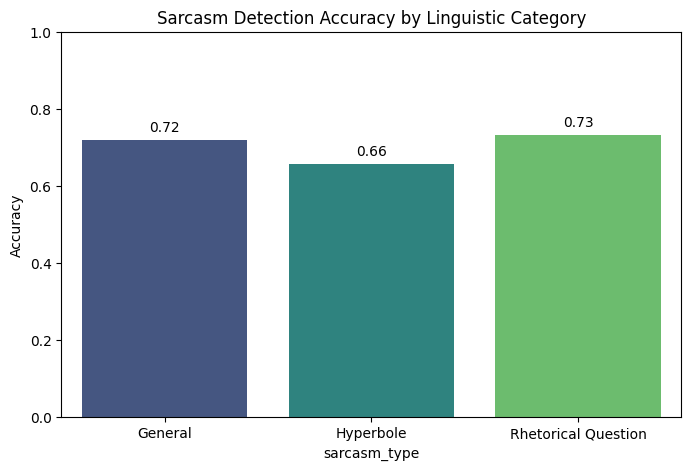

In [ ]:
# --- SEGMENT 5: ERROR ANALYSIS BY SARCASM TYPE ---

# 1. Create a results DataFrame
test_results = df_master.loc[indices_test].copy()
test_results['prediction'] = svm_pred
test_results['correct'] = test_results['label'] == test_results['prediction']

# 2. Calculate Accuracy per Type
type_accuracy = test_results.groupby('sarcasm_type')['correct'].mean()

print("\n--- MODEL PERFORMANCE BY SARCASM TYPE ---")
print(type_accuracy.sort_values(ascending=False))

# 3. Visualization
plt.figure(figsize=(8, 5))
barplot = sns.barplot(x=type_accuracy.index, y=type_accuracy.values, hue=type_accuracy.index, legend=False, palette='viridis')
plt.title('Sarcasm Detection Accuracy by Linguistic Category')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')
plt.show()

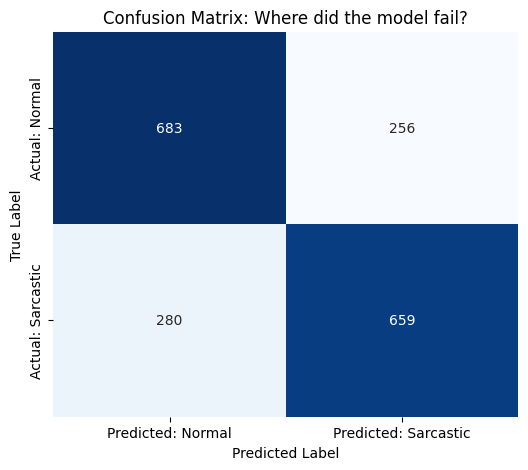

In [ ]:
# --- SEGMENT 6: THE CONFUSION MATRIX ---

# 1. Generate the matrix
cm = confusion_matrix(y_test, svm_pred)

# 2. Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Normal', 'Predicted: Sarcastic'],
            yticklabels=['Actual: Normal', 'Actual: Sarcastic'])
plt.title('Confusion Matrix: Where did the model fail?')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# --- SEGMENT 7: MANUAL "REAL WORLD" TESTING ---
warnings.filterwarnings("ignore", category=UserWarning)

def predict_sarcasm(sentence):
    clean_sentence = clean_sarcasm_text(sentence)

    # 1. Transform Text (TF-IDF)
    vec_text = tfidf.transform([clean_sentence])

    # 2. Extract Manual Features
    exc_count = sentence.count('!')
    q_count = sentence.count('?')
    caps_ratio = sum(1 for c in sentence if c.isupper()) / (len(sentence) + 1)

    # 3. Scale Manual Features
    vec_manual = scaler.transform([[exc_count, q_count, caps_ratio]])

    # 4. Combine
    vec_final = hstack([vec_text, vec_manual])

    # 5. Predict
    prediction = svm_model.predict(vec_final)[0]
    confidence = svm_model.decision_function(vec_final)[0]

    label = "SARCASTIC" if prediction == 1 else "NOT SARCASTIC"

    print(f"Input:    '{sentence}'")
    print(f"Verdict:  {label}")
    print(f"Score:    {confidence:.2f} (Positive = Sarcastic, Negative = Normal)")
    print("-" * 40)

# --- TEST ZONE ---
print("--- TESTING HYPOTHESIS ---\n")

# Test 1: Obvious RQ (Model should be CONFIDENT)
predict_sarcasm("Oh, do you really think I was born yesterday?")

# Test 2: Hyperbole (Model should be UNSURE)
predict_sarcasm("This download is taking 500 years to finish.")

# Test 3: Normal Complaint
predict_sarcasm("Hami")

--- TESTING HYPOTHESIS ---

Input:    'Oh, do you really think I was born yesterday?'
Verdict:  SARCASTIC
Score:    0.88 (Positive = Sarcastic, Negative = Normal)
----------------------------------------
Input:    'This download is taking 500 years to finish.'
Verdict:  SARCASTIC
Score:    0.30 (Positive = Sarcastic, Negative = Normal)
----------------------------------------
Input:    'Hamid, I genuinely think you're a good person.'
Verdict:  NOT SARCASTIC
Score:    -0.06 (Positive = Sarcastic, Negative = Normal)
----------------------------------------


### **8. Kesimpulan dan Analisis**

Dalam eksperimen ini, kami bergerak melampaui deteksi sarkasme biner untuk menganalisis bagaimana perangkat linguistik yang berbeda memengaruhi kinerja model. Menggunakan dataset ~9.300 sampel, kami menemukan bahwa:

1.  **Keunggulan "Struktural":** Model bekerja paling baik pada **Pertanyaan Retoris (Akurasi 73,3%)**. Hal ini menunjukkan bahwa isyarat struktural (tanda tanya, awalan kalimat tertentu) adalah indikator yang andal bagi model AI, yang memvalidasi keputusan kami untuk merekayasa fitur berbasis tanda baca.

2.  **Kesenjangan "Konteks":** Model masih mengalami kesulitan dengan **Hiperbola (Akurasi 65,6%)**. Meskipun ada peningkatan setelah perbaikan fitur, akurasinya tetap tertinggal ~8% dibandingkan Pertanyaan Retoris. Hal ini menyoroti keterbatasan dalam NLP standar: mendeteksi makna yang dilebih-lebihkan memerlukan "pengetahuan dunia" (misalnya, mengetahui bahwa "500 tahun" mustahil bagi durasi unduhan). Tanpa konteks eksternal, model sulit membedakan antusiasme dari ejekan.

3.  **Pemilihan Model:** Secara mengejutkan, baseline **Naive Bayes (72,8%)** masih sedikit mengungguli **Linear SVM (71,5%)**. Meskipun selisihnya menipis setelah perbaikan metodologi, ini mengindikasikan bahwa asumsi independensi Naive Bayes sangat tangguh (robust) terhadap data teks yang penuh noise, sedangkan SVM mungkin memerlukan kernel non-linear atau data yang lebih banyak untuk menangkap pola sarkasme yang kompleks.